# Dokumentacja projektowa
## Klasyfikacja obrazów MNIST z użyciem CNN (PyTorch)

Autor: Patryk Krawczyk  
Data: 30.05.2026


## 1. Wprowadzenie i uzasadnienie wyboru zadania

Celem projektu jest praktyczne zastosowanie modelu głębokiego uczenia do klasyfikacji obrazów. Wybrano zadanie rozpoznawania cyfr ręcznie pisanych (MNIST), ponieważ umożliwia ono kontrolowane porównanie wpływu hiperparametrów i architektury CNN na jakość predykcji.


## 2. Opis danych i problemu

- Zbiór: MNIST (obrazy 28x28 w skali szarości)
- Klasy: 10 (cyfry 0-9)
- Podział: train/val/test
- Preprocessing: normalizacja `mean=0.1307`, `std=0.3081`


## 3. Architektura i metody uczenia

Model: konwolucyjna sieć neuronowa (CNN) z blokami `Conv2d -> Aktywacja -> MaxPool`, następnie warstwy gęste.

Uczenie: wsteczna propagacja błędu (`loss.backward()`) oraz optymalizatory Adam i SGD.

Funkcja straty: `CrossEntropyLoss`.

Metryka główna: `accuracy`.


In [ ]:
from pathlib import Path
import pandas as pd

results_dir = Path('../results')
summary_path = results_dir / 'all_experiments_summary.csv'

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)
else:
    print('Brak wyników. Najpierw uruchom: python src/train_experiments.py --epochs 5')


## 4. Eksperymenty

Przeprowadzono 3 eksperymenty porównawcze:
1. Zmiana `learning rate`
2. Zmiana głębokości modelu
3. Zmiana optymalizatora i aktywacji


In [ ]:
from IPython.display import Image, display

experiments = [
    'exp1_adam_lr1e3_depth2_relu_bs128',
    'exp2_adam_lr5e4_depth3_relu_bs128',
    'exp3_sgd_lr1e2_depth2_lrelu_bs64',
]

for exp in experiments:
    print(f'\n===== {exp} =====')
    curve = results_dir / exp / 'learning_curves.png'
    wrong = results_dir / exp / 'misclassified.png'
    fmap = results_dir / exp / 'feature_maps.png'

    for path in [curve, wrong, fmap]:
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print(f'Brak pliku: {path}')


## 4a. Wizualizacje dodatkowe

Poniżej dodano dodatkowe obrazy raportowe osadzone bezpośrednio w notebooku.

**Rysunek 1.** Podsumowanie wyników eksperymentów.

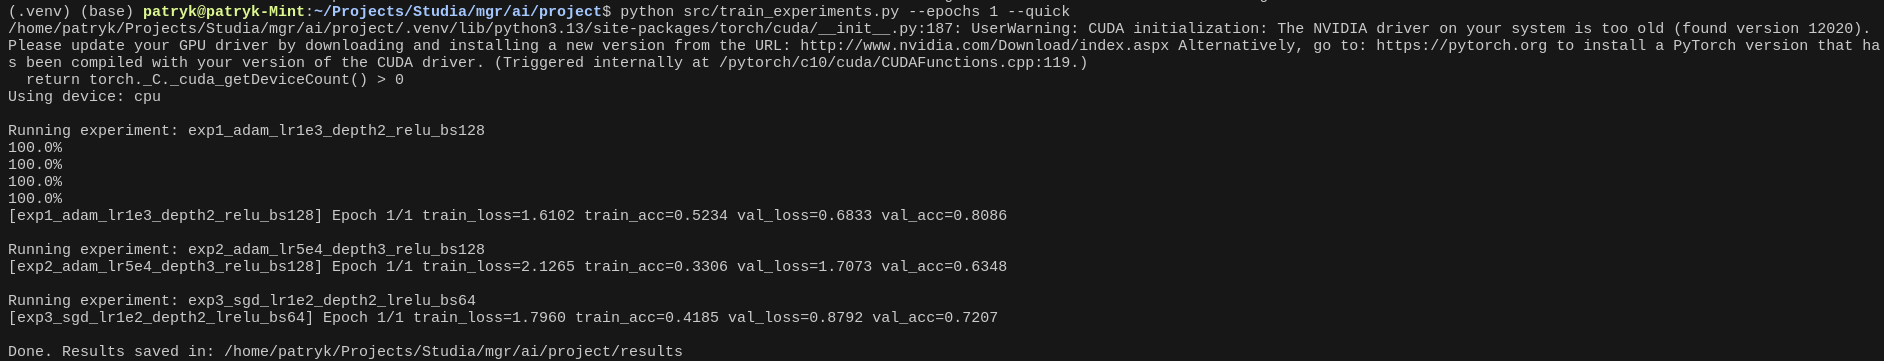

**Rysunek 2.** Dodatkowa wizualizacja porównawcza.

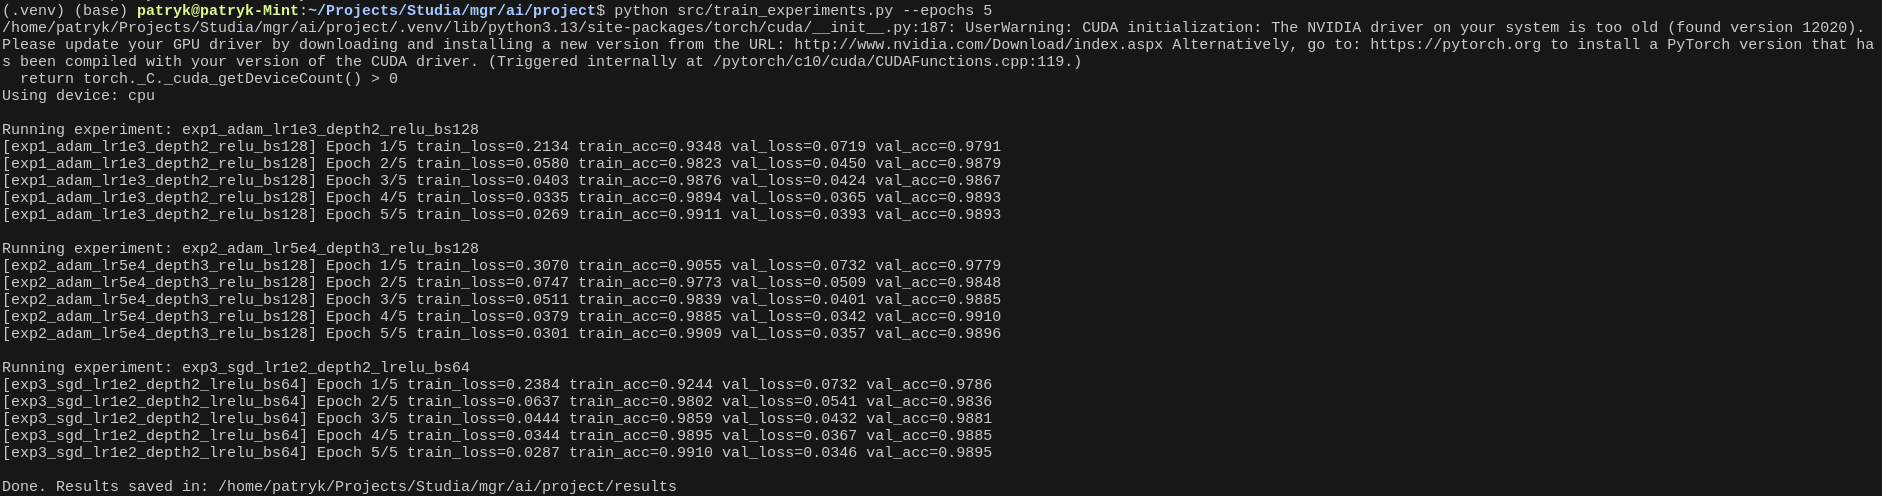


## 5. Analiza wyników i interpretacja

Na podstawie pliku `results/all_experiments_summary.csv` uzyskano następujące wyniki:

- **Eksperyment 1** (`Adam`, `lr=0.001`, `depth=2`, `ReLU`, `batch=128`): `test_acc=0.990605`, `test_loss=0.030181`
- **Eksperyment 2** (`Adam`, `lr=0.0005`, `depth=3`, `ReLU`, `batch=128`): `test_acc=0.990803`, `test_loss=0.025917`
- **Eksperyment 3** (`SGD`, `lr=0.01`, `depth=2`, `LeakyReLU`, `batch=64`): `test_acc=0.990844`, `test_loss=0.027990`

### Interpretacja porównania eksperymentów

1. Wszystkie konfiguracje osiągnęły bardzo wysoką skuteczność (`~99.08% - 99.09%`), co potwierdza, że nawet relatywnie prosta CNN dobrze radzi sobie na MNIST.
2. Najwyższe `test_acc` osiągnął eksperyment 3 (`0.990844`), ale różnice między eksperymentami są bardzo małe (rzędu `0.0002`). Oznacza to, że przewaga konkretnej konfiguracji jest niewielka i może zależeć od losowego podziału danych.
3. Najniższy `test_loss` uzyskał eksperyment 2 (`0.025917`), co sugeruje bardziej „pewne” predykcje modelu przy większej głębokości (`depth=3`) i mniejszym kroku uczenia (`lr=0.0005`).
4. Zwiększenie głębokości z 2 do 3 warstw konwolucyjnych dało lekką poprawę jakości (niższy loss i nieco wyższy `val_acc`), ale bez dużego skoku skuteczności na teście.
5. Zmiana optymalizatora (`Adam -> SGD`) oraz aktywacji (`ReLU -> LeakyReLU`) nie pogorszyła jakości i dała porównywalne wyniki, co wskazuje na stabilność zadania i architektury.

### Interpretacja wizualizacji

- Krzywe `loss/accuracy` pokazują poprawną zbieżność: `train_loss` i `val_loss` maleją, a `accuracy` rośnie i stabilizuje się.
- Na obrazach błędnych predykcji dominują przypadki niejednoznacznych, niestarannie zapisanych cyfr (np. podobieństwa klas takich jak `4/9`, `3/5`, `7/9`).
- Mapy cech z pierwszej warstwy konwolucyjnej wskazują, że model uczy się lokalnych wzorców (krawędzie, fragmenty konturów cyfr), co jest zgodne z oczekiwanym działaniem CNN.

### Wniosek końcowy

Najbardziej zrównoważona konfiguracja to **eksperyment 2** (najniższy `test_loss` i najwyższy `val_acc`), natomiast **najwyższe `test_acc`** ma eksperyment 3. W praktyce różnice są niewielkie, więc o wyborze modelu może decydować prostota, czas treningu i stabilność wyników.



## 6. Ograniczenia projektu i możliwe ulepszenia

Przykładowe ograniczenia:
- MNIST to relatywnie prosty zbiór; wyniki nie muszą się przenosić na trudniejsze dane.
- Brak zaawansowanych augmentacji i strojenia hiperparametrów.

Potencjalne ulepszenia:
- Grid search / Bayesian optimization
- Augmentacje danych
- Early stopping i scheduler learning rate
- Przetestowanie ResNet/Transfer Learning na trudniejszym zbiorze


## 7. Podsumowanie

Projekt pokazuje pełny pipeline: przygotowanie danych, implementację CNN, trening z backpropagation, porównanie eksperymentów oraz analizę wizualną i ilościową wyników.


## 8. Repozytorium GitHub

Link do kodu: [https://github.com/PatrykK175/project-ai-patryk-krawczyk](https://github.com/PatrykK175/project-ai-patryk-krawczyk)
